# 隐藏层是怎么克服线性模型限制的

对应《动手学深度学习》**4.1 多层感知机**。用两组玩具数据把抽象的结论「看见」：

**A. 同心圆**（400 个点，两类分别是一个外环和一个内圆）—— 任何直线都分不开

1. 线性模型
2. 两层但**不加激活函数**（用来验证 4.1.1.3 那个等价性推导）
3. 4 个隐藏单元 + ReLU
4. 16-16 MLP + ReLU

**B. XOR**（4 个点）—— 只用 **2 个隐藏单元**，把隐藏空间 (h1, h2) 直接画出来

看数据怎么被「换坐标」之后变得**线性可分**，以及为什么最后一层**仍然是一条直线**。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('torch', torch.__version__, '| numpy', np.__version__)

torch 2.13.0+cu126 | numpy 2.4.6


样本数: (400, 2) | 每类数量: [200 200]


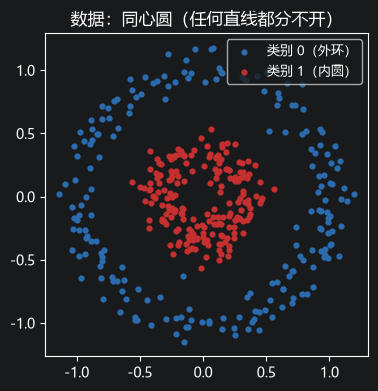

In [6]:
def make_circles(n=400, noise=0.09, seed=0):
    rng = np.random.default_rng(seed)
    n_out = n // 2
    n_in = n - n_out
    theta = rng.uniform(0, 2 * np.pi, n)
    r = np.concatenate([rng.normal(1.0, noise, n_out), rng.normal(0.35, noise, n_in)])
    label = np.concatenate([np.zeros(n_out), np.ones(n_in)])
    pts = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
    order = rng.permutation(n)
    return pts[order].astype(np.float32), label[order].astype(np.float32)


X, y = make_circles()
Xt, yt = torch.tensor(X), torch.tensor(y).view(-1, 1)
print('样本数:', X.shape, '| 每类数量:', np.bincount(y.astype(int)))

plt.figure(figsize=(4.2, 4.2))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=12, c='#2b6cb0', label='类别 0（外环）')
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=12, c='#c53030', label='类别 1（内圆）')
plt.title('数据：同心圆（任何直线都分不开）')
plt.legend(fontsize=9)
plt.gca().set_aspect('equal')
plt.show()

In [3]:
def train(model, x, t, epochs=1500, lr=0.03, seed=0):
    torch.manual_seed(seed)          # 固定初始化，保证结果可复现
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        opt.zero_grad()
        lossf(model(x), t).backward()
        opt.step()
    with torch.no_grad():
        acc = ((model(x) > 0).float() == t).float().mean().item()
    return acc, model


def boundaries(model):
    """在整个平面上求模型输出，用来画决策边界。"""
    pad = 0.3
    xs = np.arange(X[:, 0].min() - pad, X[:, 0].max() + pad, 0.02)
    ys = np.arange(X[:, 1].min() - pad, X[:, 1].max() + pad, 0.02)
    xx, yy = np.meshgrid(xs, ys)
    grid = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32))
    with torch.no_grad():
        zz = model(grid).numpy().reshape(xx.shape)
    return xx, yy, zz


def draw(ax, model, title, acc):
    xx, yy, zz = boundaries(model)
    ax.contourf(xx, yy, zz, levels=[-1e9, 0, 1e9], colors=['#cfe3ff', '#ffd9d9'])
    ax.contour(xx, yy, zz, levels=[0], colors='k', linewidths=1.3)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=10, c='#2b6cb0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10, c='#c53030')
    ax.set_title('%s\n训练准确率 %.1f%%' % (title, acc * 100), fontsize=10)
    ax.set_aspect('equal')

线性模型                     训练准确率 51.2%
两层·无激活（等价于线性）            训练准确率 51.2%
4 个隐藏单元 + ReLU           训练准确率 100.0%
16-16 MLP + ReLU         训练准确率 100.0%


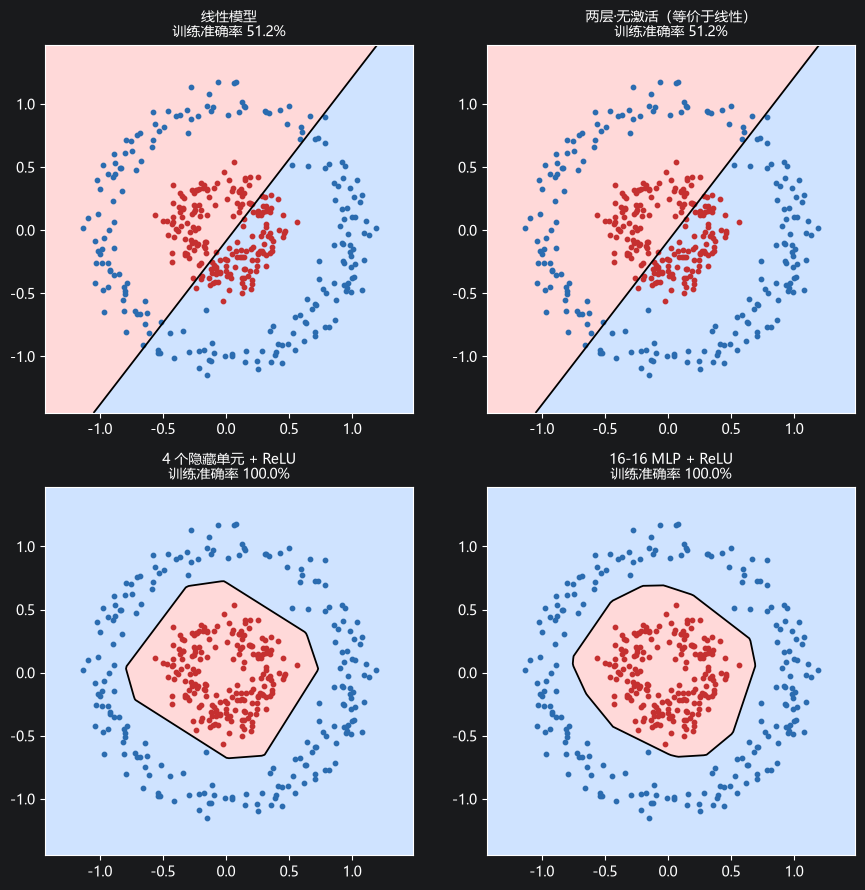

In [4]:
configs = [
    ('线性模型', lambda: nn.Linear(2, 1)),
    ('两层·无激活（等价于线性）', lambda: nn.Sequential(nn.Linear(2, 16), nn.Linear(16, 1))),
    ('4 个隐藏单元 + ReLU', lambda: nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))),
    ('16-16 MLP + ReLU', lambda: nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 16), nn.ReLU(), nn.Linear(16, 1))),
]

results = []
for name, build in configs:
    acc, m = train(build(), Xt, yt)
    results.append((name, m, acc))
    print('%-24s 训练准确率 %.1f%%' % (name, acc * 100))

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (name, m, acc) in zip(axes.ravel(), results):
    draw(ax, m, name, acc)
plt.tight_layout()
plt.show()

## 图里能看到什么（同心圆）

实测结果（固定随机种子，你的机器上应当一致）：

| 模型 | 训练准确率 | 决策边界 |
|---|---|---|
| 线性模型 | **51.2%** | 一条直线，基本等于瞎猜 |
| 两层·无激活 | **51.2%** | 还是一条直线，和上面**一模一样** |
| 4 个隐藏单元 + ReLU | **100%** | 变成闭合曲线，把内圆圈起来 |
| 16-16 MLP + ReLU | **100%** | 更平滑的闭合曲线 |

**要点一：** 两层不加激活，准确率和线性模型分毫不差 —— 这正是 d2l 4.1.1.3 的代数结论：

```
O = (XW⁽¹⁾ + b⁽¹⁾)W⁽²⁾ + b⁽²⁾ = XW + b
其中 W = W⁽¹⁾W⁽²⁾,  b = b⁽¹⁾W⁽²⁾ + b⁽²⁾
```

仿射函数的仿射函数还是仿射函数，**深度白加了**。

**要点二：** 加了 ReLU 之后边界会弯，但**输出层仍然是线性的** —— 弯曲完全来自隐藏层的非线性。所以弯的东西不是「最后一层变聪明了」，而是隐藏层把数据搬到了一个能被直线切开的地方。

**要点三：** 16-16 和 4 个单元在这道题上都是 100%，说明「更宽」不是免费的收益，参数越多越容易过拟合（见 4.4 欠拟合与过拟合、4.5 权重衰减、4.6 暂退法）。

2 单元 + tanh  -> 准确率 100% | 隐藏空间坐标 h:
     [[-0.984000027179718, -0.9679999947547913], [0.9850000143051147, -1.0], [-1.0, 0.9819999933242798], [-0.9860000014305115, -0.984000027179718]]
2 单元 + ReLU  -> 准确率  50% | 隐藏空间坐标 h:
     [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]


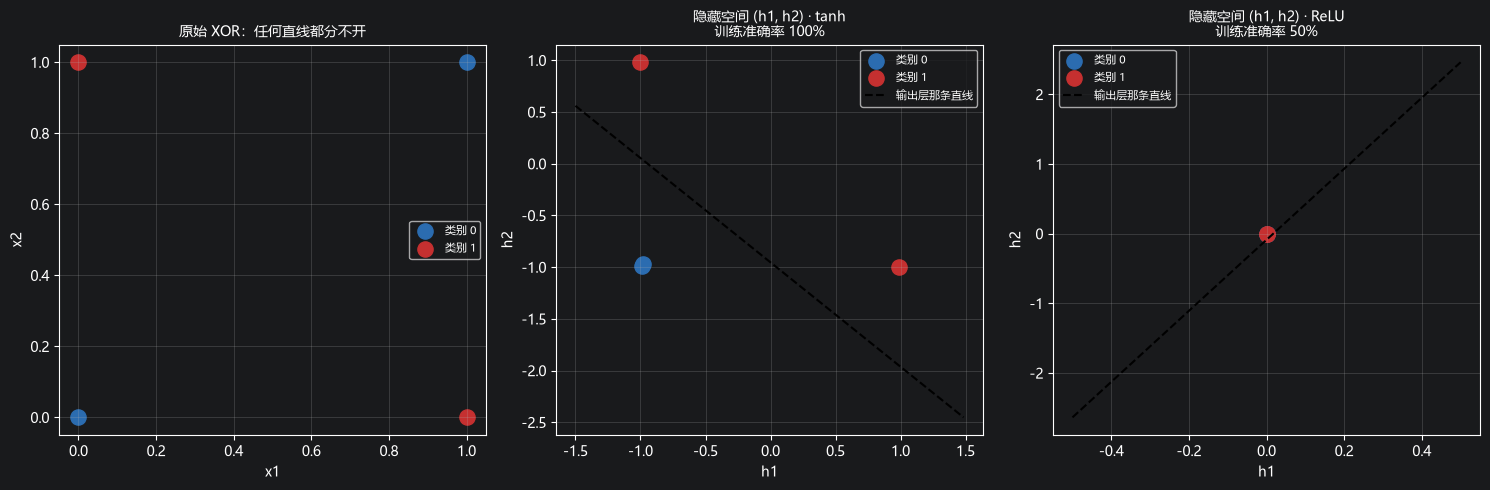

In [5]:
Xx = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
yx = torch.tensor([[0.], [1.], [1.], [0.]])

trained = {}
for act_name, act in [('tanh', nn.Tanh()), ('ReLU', nn.ReLU())]:
    m = nn.Sequential(nn.Linear(2, 2), act, nn.Linear(2, 1))
    acc, m = train(m, Xx, yx, epochs=2000, lr=0.05)
    trained[act_name] = (m, acc)
    with torch.no_grad():
        h = m[1](m[0](Xx)).numpy()
    print('2 单元 + %-5s -> 准确率 %3.0f%% | 隐藏空间坐标 h:' % (act_name, acc * 100))
    print('    ', np.round(h, 3).tolist())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(Xx[yx.view(-1) == 0, 0], Xx[yx.view(-1) == 0, 1], s=120, c='#2b6cb0', label='类别 0')
ax.scatter(Xx[yx.view(-1) == 1, 0], Xx[yx.view(-1) == 1, 1], s=120, c='#c53030', label='类别 1')
ax.set_title('原始 XOR：任何直线都分不开', fontsize=10)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

for ax, act_name in [(axes[1], 'tanh'), (axes[2], 'ReLU')]:
    m, acc = trained[act_name]
    with torch.no_grad():
        h = m[1](m[0](Xx)).numpy()      # 隐藏层输出 = 数据在新空间里的坐标
    ax.scatter(h[yx.view(-1) == 0, 0], h[yx.view(-1) == 0, 1], s=120, c='#2b6cb0', label='类别 0')
    ax.scatter(h[yx.view(-1) == 1, 0], h[yx.view(-1) == 1, 1], s=120, c='#c53030', label='类别 1')
    w = m[2].weight.detach().numpy().ravel()   # 输出层权重
    b = m[2].bias.item()
    if abs(w[1]) > 1e-6:                       # 画出 w·h + b = 0 这条直线
        lo, hi = h.min() - 0.5, h.max() + 0.5
        xs = np.linspace(lo, hi, 50)
        ax.plot(xs, -(w[0] * xs + b) / w[1], 'k--', lw=1.5, label='输出层那条直线')
    ax.set_title('隐藏空间 (h1, h2) · %s\n训练准确率 %.0f%%' % (act_name, acc * 100), fontsize=10)
    ax.set_xlabel('h1')
    ax.set_ylabel('h2')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 图里能看到什么（XOR 与隐藏空间）

- **tanh 版（100%）**：四组坐标被折成**两团**——类别 0 落在左下角，类别 1 落在右上/右下，于是输出层用**一条直线（黑色虚线）**就能分开。这就是「隐藏层 = 换一套坐标」的字面意思：
  - 类别 0 的 h ≈ (-0.98, -0.97)
  - 类别 1 的 h ≈ (0.99, -1.00) 和 (-1.00, 0.98)
  - 分界线大约是 h1 + h2 = -1
- **ReLU 版（50%）**：四个点的隐藏坐标**全是 (0, 0)** —— 两个单元对全部样本都输出 0，隐藏空间塌成一个点，梯度也变成 0，网络再也学不动。这就是实践里著名的**死 ReLU（dying ReLU）**：小网络 + 固定初始化时，有时会完全卡在瞎猜水平。

所以「隐藏层能克服线性模型的限制」这句话，准确的说法是：

1. **它学的是一个表示（换坐标）**：前 L−1 层负责把数据搬到某个空间，最后一层仍是**线性预测器**在那个空间里划一刀；
2. **这个表示是和数据一起学出来的**（我们人算不出该用什么特征，所以让梯度去决定）；
3. **非线性激活 σ 不可省**：去掉它，整张网立刻塌回 `XW + b`（上面同心圆那张图已经实测：两层无激活 = 51.2% = 线性模型）；
4. **能学会 ≠ 一定学会**：ReLU 会死、小容量不够（同数据上 2 个单元只有 50%~85%，4 个单元才 100%），这属于优化/容量问题，不是理论上的表达力问题。

## 可以自己动手改的地方

1. 把 `4 个隐藏单元` 改成 `2 个`，多跑几次（改 `train(..., seed=...)`）——你会看到 50% 和 85% 交替出现，亲手复现「容量不够 / 死 ReLU」。
2. 把 ReLU 换成 `nn.Sigmoid()`，观察损失收敛速度（对照 4.1.2.2：sigmoid 导数最大只有 0.25，越饱和越难学）。
3. 给 XOR 那张图把 epoch 改成 200、lr 改成 0.5，看隐藏空间在训练过程中是怎么一步步被「折开」的（可以每个 epoch 存一张 h 的散点图做成动图）。